# 09 · Selección final del modelo en validación

Compara los dos candidatos finales, **YOLO26s 768→768** (entrenado y evaluado a
768 px) y **YOLOv8s 768→640** (entrenado a 768 y evaluado a 640 px), y elige el
modelo y sus umbrales. Solo usa validación; el test no interviene.

## Guía de lectura y ejecución

| Aspecto | Descripción |
|---|---|
| **Papel en el proyecto** | Elige el modelo final y sus umbrales usando solo validación. |
| **Cuándo abrirlo** | Para ver por qué se eligió YOLO26s a 768 px con umbrales 0,36 (humo) y 0,16 (fuego) (Sección 4.5 de la memoria). |
| **Comportamiento por defecto** | Muestra los resultados guardados (`RUN_SELECTION=False`). No usa test. |
| **Entradas principales** | Predicciones de validación de YOLO26s 768→768 y YOLOv8s 768→640. |
| **Salidas principales** | Resumen de la selección en `artifacts/12_final_validation_selection/`. |
| **Continuación** | Congelación del modelo (`tools/freeze_final_model.py`) y `10_DFire_comparacion_todos_modelos_1pct.ipynb`. |

> **Para ejecutarlo:** usar el entorno Docker de notebooks (sección 4 del
> `README.md` principal). Volver a ejecutarlo requiere resultados intermedios
> (`artifacts/experiments/` y otras carpetas de `artifacts/`) que no están en el
> repositorio; ver `notebooks/README.md`.

## Resumen

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import pandas as pd
import yaml
from IPython.display import display, Markdown, Image

roots = [Path(os.environ["TFM_PROJECT_ROOT"])] if os.environ.get("TFM_PROJECT_ROOT") else []
roots += [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((path for path in roots if (path / "tfm_pipeline.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Abrir el notebook dentro de TFM o definir TFM_PROJECT_ROOT.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import tfm_pipeline as pipeline

CONFIG_PATH = PROJECT_ROOT / "configs" / "final_validation_selection.yaml"
RUN_SELECTION = False  # True recalcula tablas desde predicciones de validación en caché.
config = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
assert config["split"] == "val" and config["test_locked"] is True

if RUN_SELECTION:
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "tools" / "run_final_validation_selection.py"),
         "--config", str(CONFIG_PATH)], check=True, cwd=PROJECT_ROOT,
    )

latest = pipeline.read_json(PROJECT_ROOT / config["output_parent"] / "latest.json")
RUN_DIR = PROJECT_ROOT / latest["run_rel"]
summary = pipeline.read_json(RUN_DIR / "run_summary.json")
assert summary["split"] == "val" and summary["test_inference_executed"] is False
assert not any(summary["source_test_flags"])

operating = pd.read_csv(RUN_DIR / "final_operating_points.csv").sort_values("selection_rank")
winner = operating.iloc[0]
display(Markdown(
    f"**Selección:** {winner['label']} · humo **{winner.smoke_threshold:.2f}** · "
    f"fuego **{winner.fire_threshold:.2f}**.  \n"
    f"Recall macro **{winner.macro_recall:.2%}**, F1 micro **{winner.micro_f1:.2%}** "
    f"y alarmas en **{int(winner.negative_images_with_alarm)}/{int(winner.negative_images)}** "
    f"negativas ({winner.negative_alarm_rate:.3%})."
))


**Selección:** YOLO26s 768→768 · humo **0.36** · fuego **0.16**.  
Recall macro **78.95%**, F1 micro **73.52%** y alarmas en **7/783** negativas (0.894%).

## Criterio

- Primero se exige que, como mucho, un **1 % de las imágenes sin humo ni
  fuego** tenga alguna alarma. Con 783 imágenes de ese tipo, el máximo es 7
  (8 ya sería un 1,02 %).
- Dentro de ese límite se elige lo que dé mayor recall medio de humo y fuego.
- Humo y fuego tienen umbrales distintos.
- Hay un solo entrenamiento por modelo, así que el resultado es la mejor opción
  antes de test, no una medida definitiva de cómo generaliza.

### 1. Comprobación de los datos de entrada

In [2]:
verification = subprocess.run(
    [sys.executable, str(PROJECT_ROOT / "tools" / "verify_final_validation_selection.py")],
    check=True, cwd=PROJECT_ROOT, capture_output=True, text=True,
)
verification_report = json.loads(verification.stdout)
display(pd.DataFrame([verification_report]))

source_rows = []
for source_name, pointer in summary["source_runs"].items():
    source_rows.append({"fuente": source_name, "run_id": pointer["run_id"], "ruta": pointer["run_rel"]})
display(pd.DataFrame(source_rows))


,status,run_id,selected_candidate,smoke_threshold,fire_threshold,negative_alarm_rate,images,negative_images,grid_points,test_inference_executed
0,passed,20260914T205147Z_65e09e1b,yolo26s,0.36,0.16,0.00894,1721,783,4050,False


,fuente,run_id,ruta
0,architecture,20260912T222802Z_a9b49dd6,artifacts/09_architecture_768_comparison/valid...
1,threshold_review,20260913T092050Z_11e54fc4,artifacts/10_class_threshold_fp_review/validat...


## Datos

Se usan las 1.721 imágenes de validación (783 sin humo ni fuego). Cada modelo
se ejecutó una vez con confianza mínima 0,01 y, a partir de esas predicciones,
se evaluaron 2.025 parejas de umbrales (de 0,16 a 0,60, en pasos de 0,01, para
cada clase). Una detección es correcta si solapa al menos un 50 % con la caja
real.

In [3]:
class_metrics = pd.read_csv(RUN_DIR / "class_metrics.csv")
size_metrics = pd.read_csv(RUN_DIR / "size_metrics.csv")
errors = pd.read_csv(RUN_DIR / "error_comparison.csv")
standard = pd.read_csv(RUN_DIR / "standard_metrics.csv")
paired = pd.read_csv(RUN_DIR / "paired_comparison_768.csv")
threshold_grid = pd.read_csv(RUN_DIR / "class_threshold_grid_01pct.csv")

coverage = pd.DataFrame([{
    "imágenes": int(winner.images),
    "negativas": int(winner.negative_images),
    "modelos": operating.candidate.nunique(),
    "parejas de umbral": len(threshold_grid),
    "parejas por modelo": len(threshold_grid) // operating.candidate.nunique(),
    "test consultado": summary["test_inference_executed"],
}])
display(coverage)


,imágenes,negativas,modelos,parejas de umbral,parejas por modelo,test consultado
0,1721,783,2,4050,2025,False


## Resultados

### 2. Comparación con el límite del 1 %

Rango,Modelo,Umbral humo,Umbral fuego,Precisión micro,Recall micro,F1 micro,Recall macro,Recall mínimo,Negativas con alarma,Tasa alarma negativa
1,YOLO26s 768→768,0.36,0.16,68.82%,78.91%,73.52%,78.95%,78.53%,7,0.894%
2,YOLOv8s 768→640,0.49,0.17,68.84%,77.21%,72.79%,77.08%,75.62%,7,0.894%


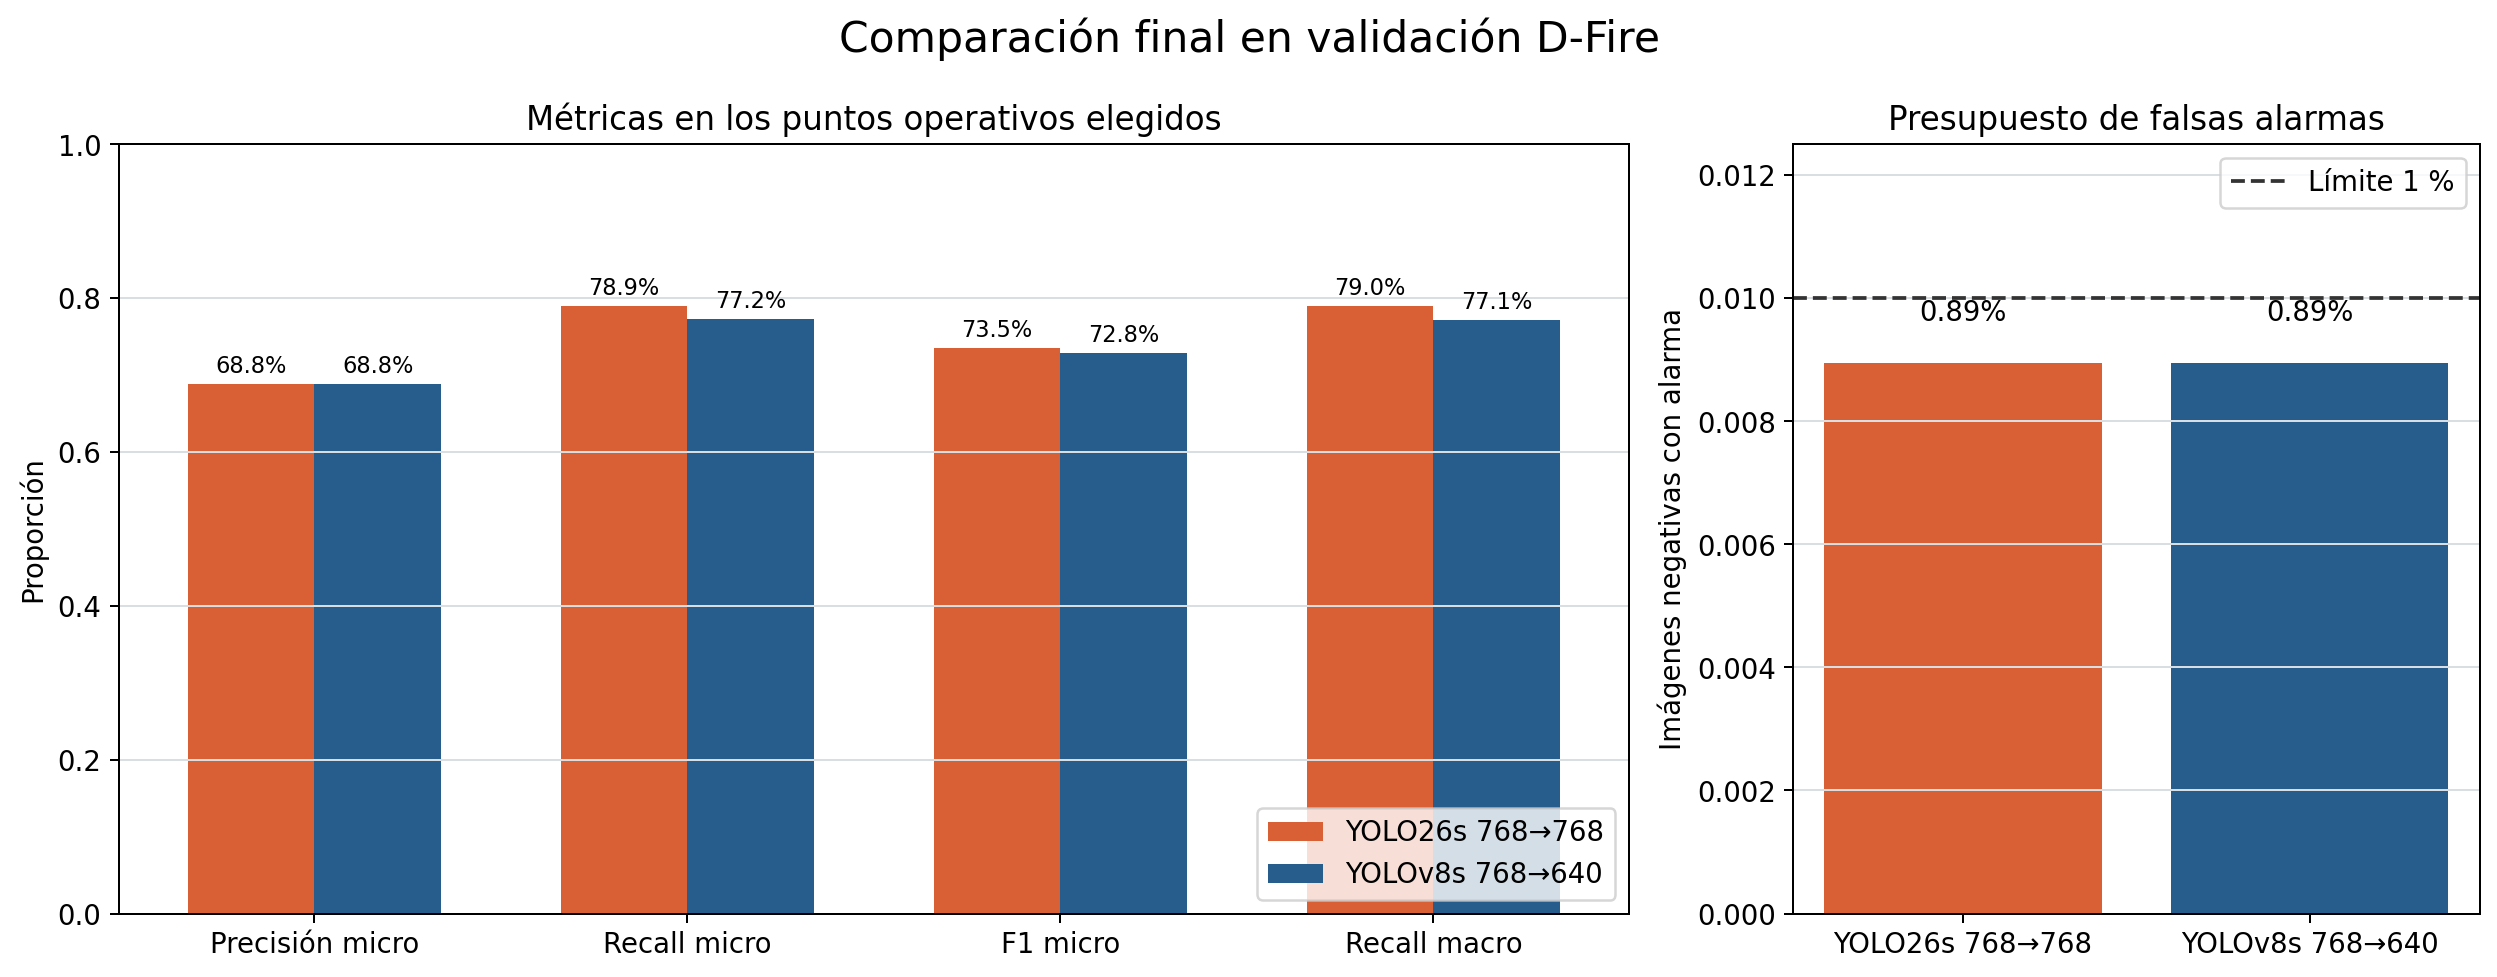

In [4]:
global_columns = [
    "selection_rank", "label", "smoke_threshold", "fire_threshold",
    "micro_precision", "micro_recall", "micro_f1", "macro_recall",
    "minimum_class_recall", "negative_images_with_alarm", "negative_alarm_rate",
]
global_table = operating[global_columns].rename(columns={
    "selection_rank": "Rango", "label": "Modelo", "smoke_threshold": "Umbral humo",
    "fire_threshold": "Umbral fuego", "micro_precision": "Precisión micro",
    "micro_recall": "Recall micro", "micro_f1": "F1 micro",
    "macro_recall": "Recall macro", "minimum_class_recall": "Recall mínimo",
    "negative_images_with_alarm": "Negativas con alarma",
    "negative_alarm_rate": "Tasa alarma negativa",
})
display(global_table.style.format({
    "Umbral humo": "{:.2f}", "Umbral fuego": "{:.2f}",
    "Precisión micro": "{:.2%}", "Recall micro": "{:.2%}", "F1 micro": "{:.2%}",
    "Recall macro": "{:.2%}", "Recall mínimo": "{:.2%}", "Tasa alarma negativa": "{:.3%}",
}).hide(axis="index"))
display(Image(filename=str(RUN_DIR / "figures" / "01_global_operating_comparison.png"), width=1100))


Los dos modelos dan alarma en 7 de las 783 imágenes sin humo ni fuego. Se
elige YOLO26s porque tiene mayor recall medio, mayor recall en la clase más
débil y mayor F1, con una precisión prácticamente igual.

### 3. Límite del 1 % frente al 2 %

Modelo,Presupuesto,Umbral humo,Umbral fuego,Precisión micro,Recall micro,F1 micro,Recall macro,Negativas con alarma,Tasa observada
YOLO26s 768→768,1%,0.36,0.16,68.82%,78.91%,73.52%,78.95%,7,0.894%
YOLO26s 768→768,2%,0.16,0.16,64.97%,81.65%,72.37%,81.97%,12,1.533%
YOLOv8s 768→640,1%,0.49,0.17,68.84%,77.21%,72.79%,77.08%,7,0.894%
YOLOv8s 768→640,2%,0.28,0.16,65.37%,80.24%,72.04%,80.35%,15,1.916%


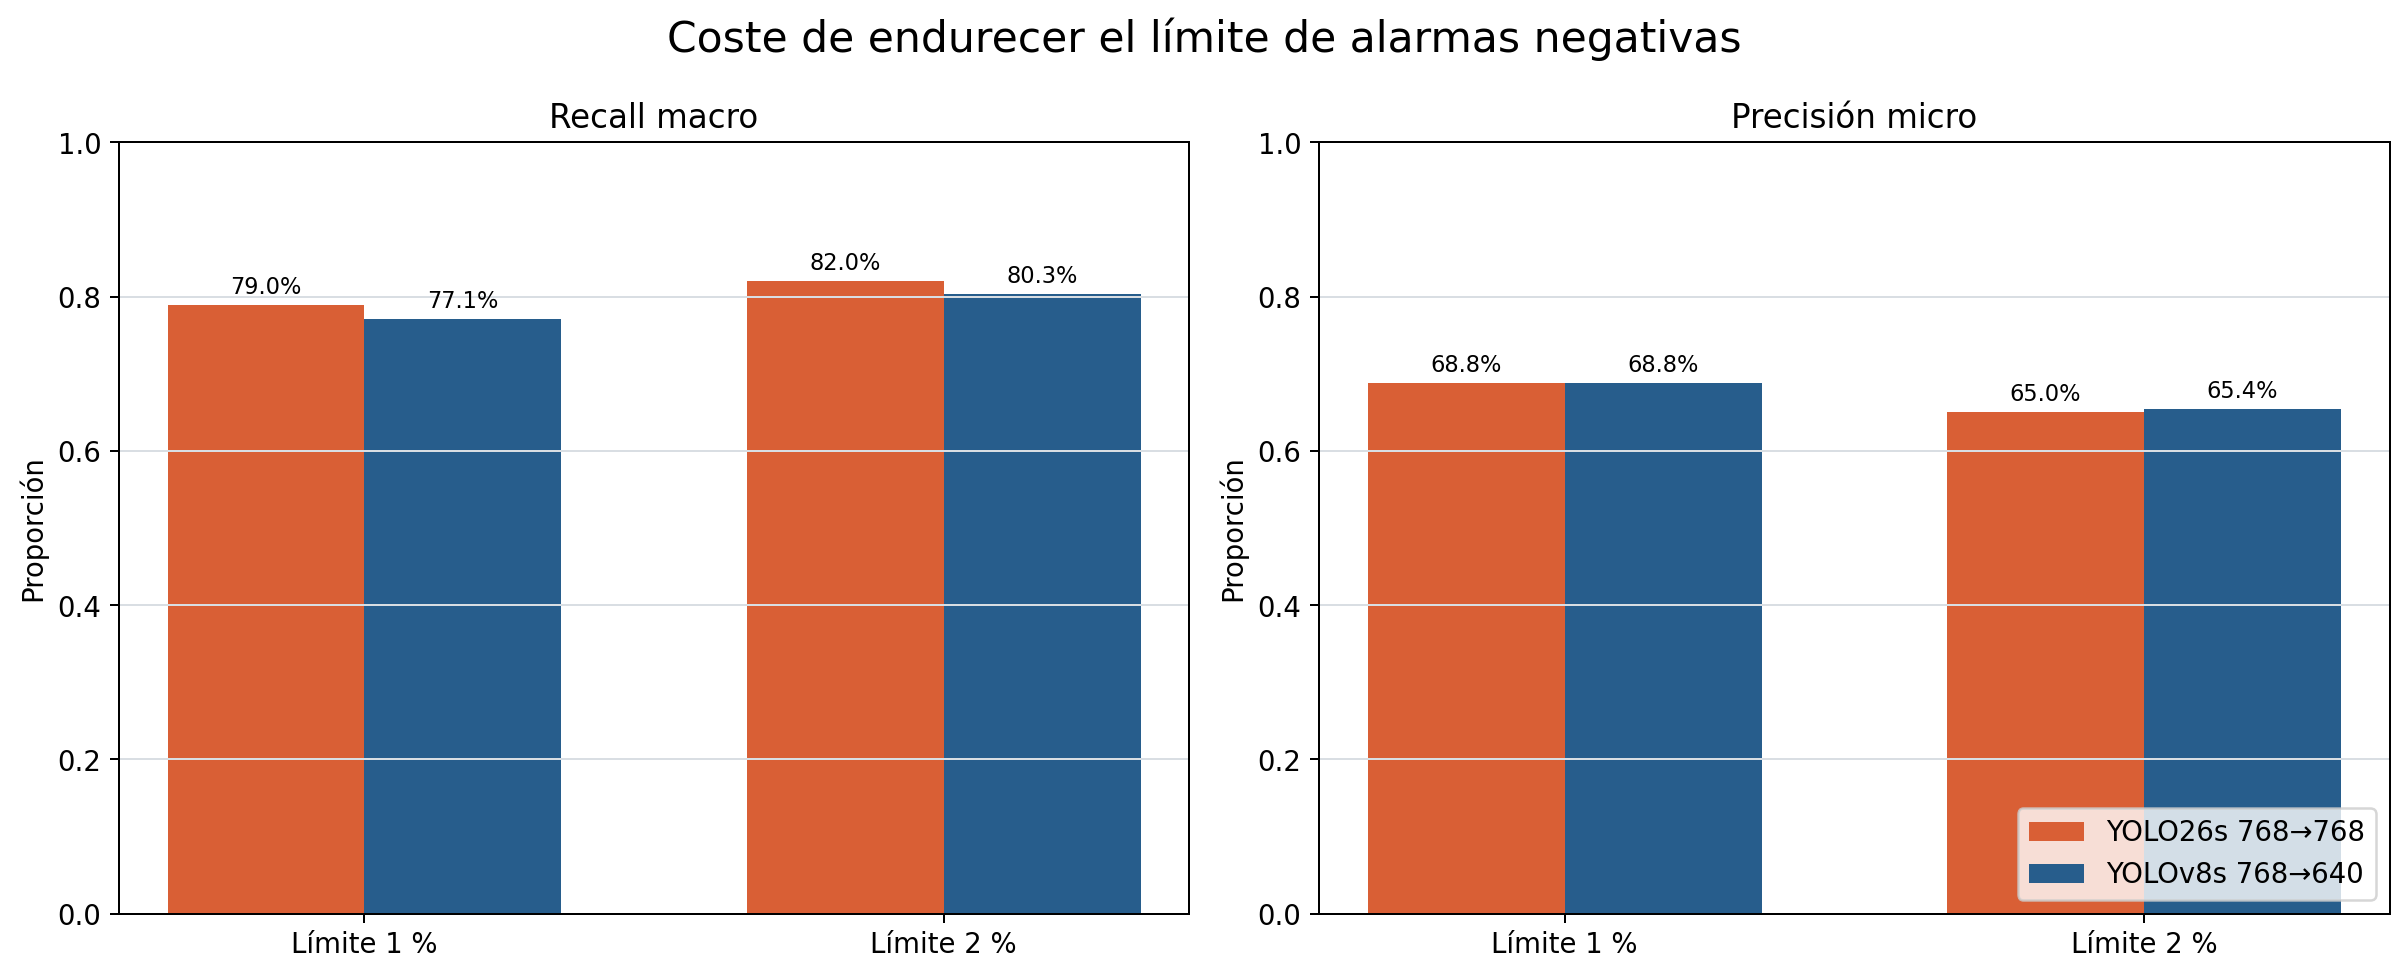

In [5]:
budget_comparison = pd.read_csv(RUN_DIR / "alarm_budget_comparison.csv")
budget_table = budget_comparison[[
    "label", "alarm_budget", "smoke_threshold", "fire_threshold",
    "micro_precision", "micro_recall", "micro_f1", "macro_recall",
    "negative_images_with_alarm", "negative_alarm_rate",
]].rename(columns={
    "label": "Modelo", "alarm_budget": "Presupuesto", "smoke_threshold": "Umbral humo",
    "fire_threshold": "Umbral fuego", "micro_precision": "Precisión micro",
    "micro_recall": "Recall micro", "micro_f1": "F1 micro", "macro_recall": "Recall macro",
    "negative_images_with_alarm": "Negativas con alarma", "negative_alarm_rate": "Tasa observada",
})
display(budget_table.style.format({
    "Presupuesto": "{:.0%}", "Umbral humo": "{:.2f}", "Umbral fuego": "{:.2f}",
    "Precisión micro": "{:.2%}", "Recall micro": "{:.2%}", "F1 micro": "{:.2%}",
    "Recall macro": "{:.2%}", "Tasa observada": "{:.3%}",
}).hide(axis="index"))
display(Image(filename=str(RUN_DIR / "figures" / "04_alarm_budget_comparison.png"), width=1050))


Pasar del 2 % al 1 % baja el recall medio unos tres puntos en los dos modelos,
sobre todo porque obliga a subir el umbral de humo. A cambio mejora la
precisión. YOLO26s tiene mayor recall medio con los dos límites.

### 4. Métricas estándar y por clase

In [6]:
standard_table = standard[standard.scope == "all"][[
    "label", "precision", "recall", "mAP50", "mAP50_95", "inference_ms"
]].rename(columns={"label": "Modelo", "precision": "Precisión", "recall": "Recall",
                   "mAP50_95": "mAP50-95", "inference_ms": "Inferencia ms"})
display(standard_table.style.format({
    "Precisión": "{:.2%}", "Recall": "{:.2%}", "mAP50": "{:.2%}",
    "mAP50-95": "{:.2%}", "Inferencia ms": "{:.3f}",
}).hide(axis="index"))

class_table = class_metrics[["label", "class_name", "threshold", "precision", "recall", "f1", "tp", "fp", "fn"]].copy()
class_table["class_name"] = class_table.class_name.map({"smoke": "Humo", "fire": "Fuego"})
class_table = class_table.rename(columns={"label": "Modelo", "class_name": "Clase", "threshold": "Umbral",
    "precision": "Precisión", "recall": "Recall", "f1": "F1", "tp": "TP", "fp": "FP", "fn": "FN"})
display(class_table.style.format({"Umbral": "{:.2f}", "Precisión": "{:.2%}",
                                  "Recall": "{:.2%}", "F1": "{:.2%}"}).hide(axis="index"))


Modelo,Precisión,Recall,mAP50,mAP50-95,Inferencia ms
YOLO26s 768→768,80.43%,74.77%,80.14%,46.68%,2.242
YOLOv8s 768→640,81.65%,74.39%,80.70%,46.52%,1.662


Modelo,Clase,Umbral,Precisión,Recall,F1,TP,FP,FN
YOLO26s 768→768,Humo,0.36,85.81%,79.38%,82.47%,762,126,198
YOLO26s 768→768,Fuego,0.16,59.01%,78.53%,67.38%,907,630,248
YOLOv8s 768→640,Humo,0.49,88.86%,75.62%,81.71%,726,91,234
YOLOv8s 768→640,Fuego,0.17,58.33%,78.53%,66.94%,907,648,248


### 5. Recall por tamaño de objeto

Modelo,Clase,Tamaño,Cajas GT,TP,FN,Recall
YOLO26s 768→768,Humo,Pequeño,188,129,59,68.62%
YOLO26s 768→768,Humo,Mediano,222,150,72,67.57%
YOLO26s 768→768,Humo,Grande,550,483,67,87.82%
YOLO26s 768→768,Fuego,Pequeño,760,577,183,75.92%
YOLO26s 768→768,Fuego,Mediano,324,265,59,81.79%
YOLO26s 768→768,Fuego,Grande,71,65,6,91.55%
YOLOv8s 768→640,Humo,Pequeño,188,119,69,63.30%
YOLOv8s 768→640,Humo,Mediano,222,142,80,63.96%
YOLOv8s 768→640,Humo,Grande,550,465,85,84.55%
YOLOv8s 768→640,Fuego,Pequeño,760,580,180,76.32%


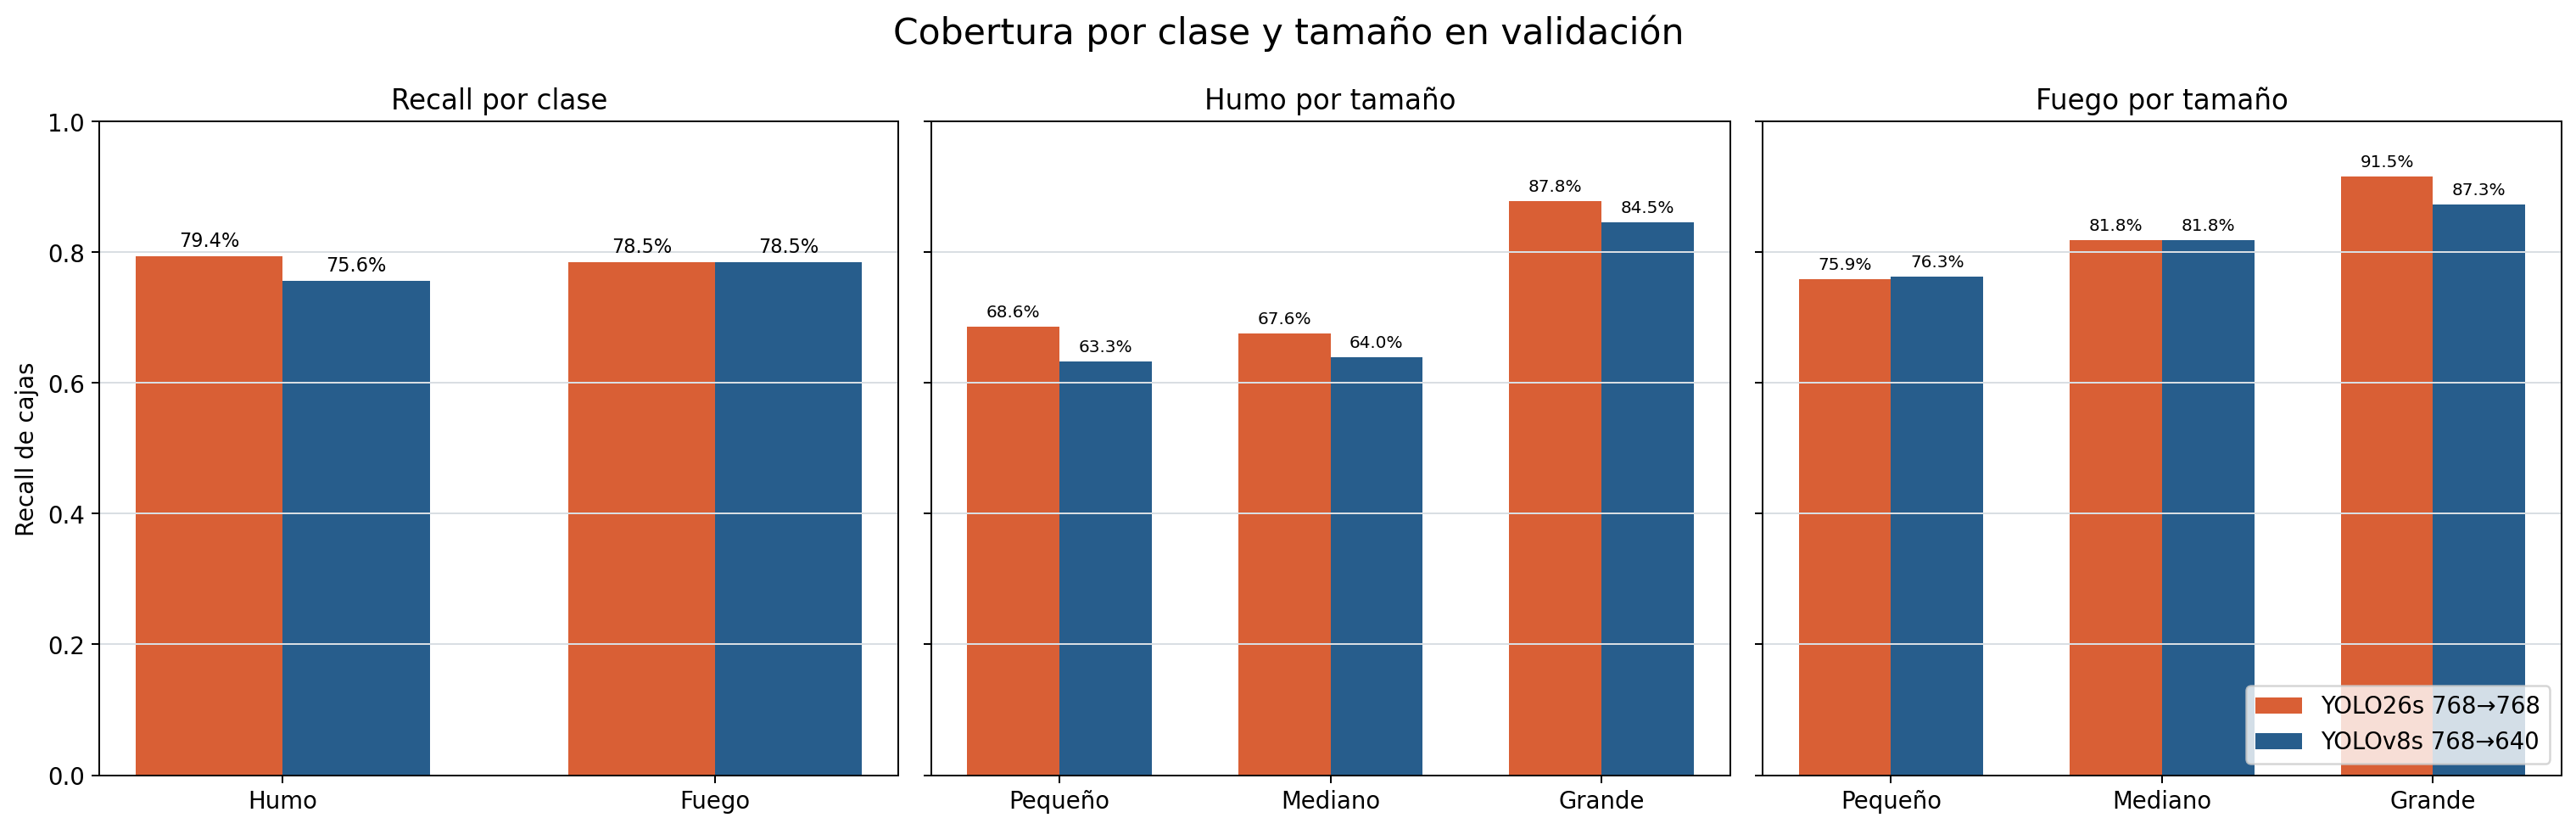

In [7]:
size_table = size_metrics[["label", "class_name", "size_band", "gt_boxes", "tp", "fn", "recall"]].copy()
size_table["class_name"] = size_table.class_name.map({"smoke": "Humo", "fire": "Fuego"})
size_table["size_band"] = size_table.size_band.map({"small": "Pequeño", "medium": "Mediano", "large": "Grande"})
size_table = size_table.rename(columns={"label": "Modelo", "class_name": "Clase", "size_band": "Tamaño",
    "gt_boxes": "Cajas GT", "tp": "TP", "fn": "FN", "recall": "Recall"})
display(size_table.style.format({"Recall": "{:.2%}"}).hide(axis="index"))
display(Image(filename=str(RUN_DIR / "figures" / "02_class_and_size_recall.png"), width=1200))


YOLO26s mejora en las tres bandas de tamaño de humo y en fuego grande, empata
en fuego mediano y queda 0,40 puntos por debajo en fuego pequeño. Las cajas
pequeñas son la mayoría en fuego (760 de 1.155).

### 6. Falsos positivos y falsos negativos

Modelo,FP humo,FN humo,FP fuego,FN fuego,FP en positivas,FP en negativas,Negativas con alarma
YOLO26s 768→768,126,198,630,248,748,8,7
YOLOv8s 768→640,91,234,648,248,729,10,7


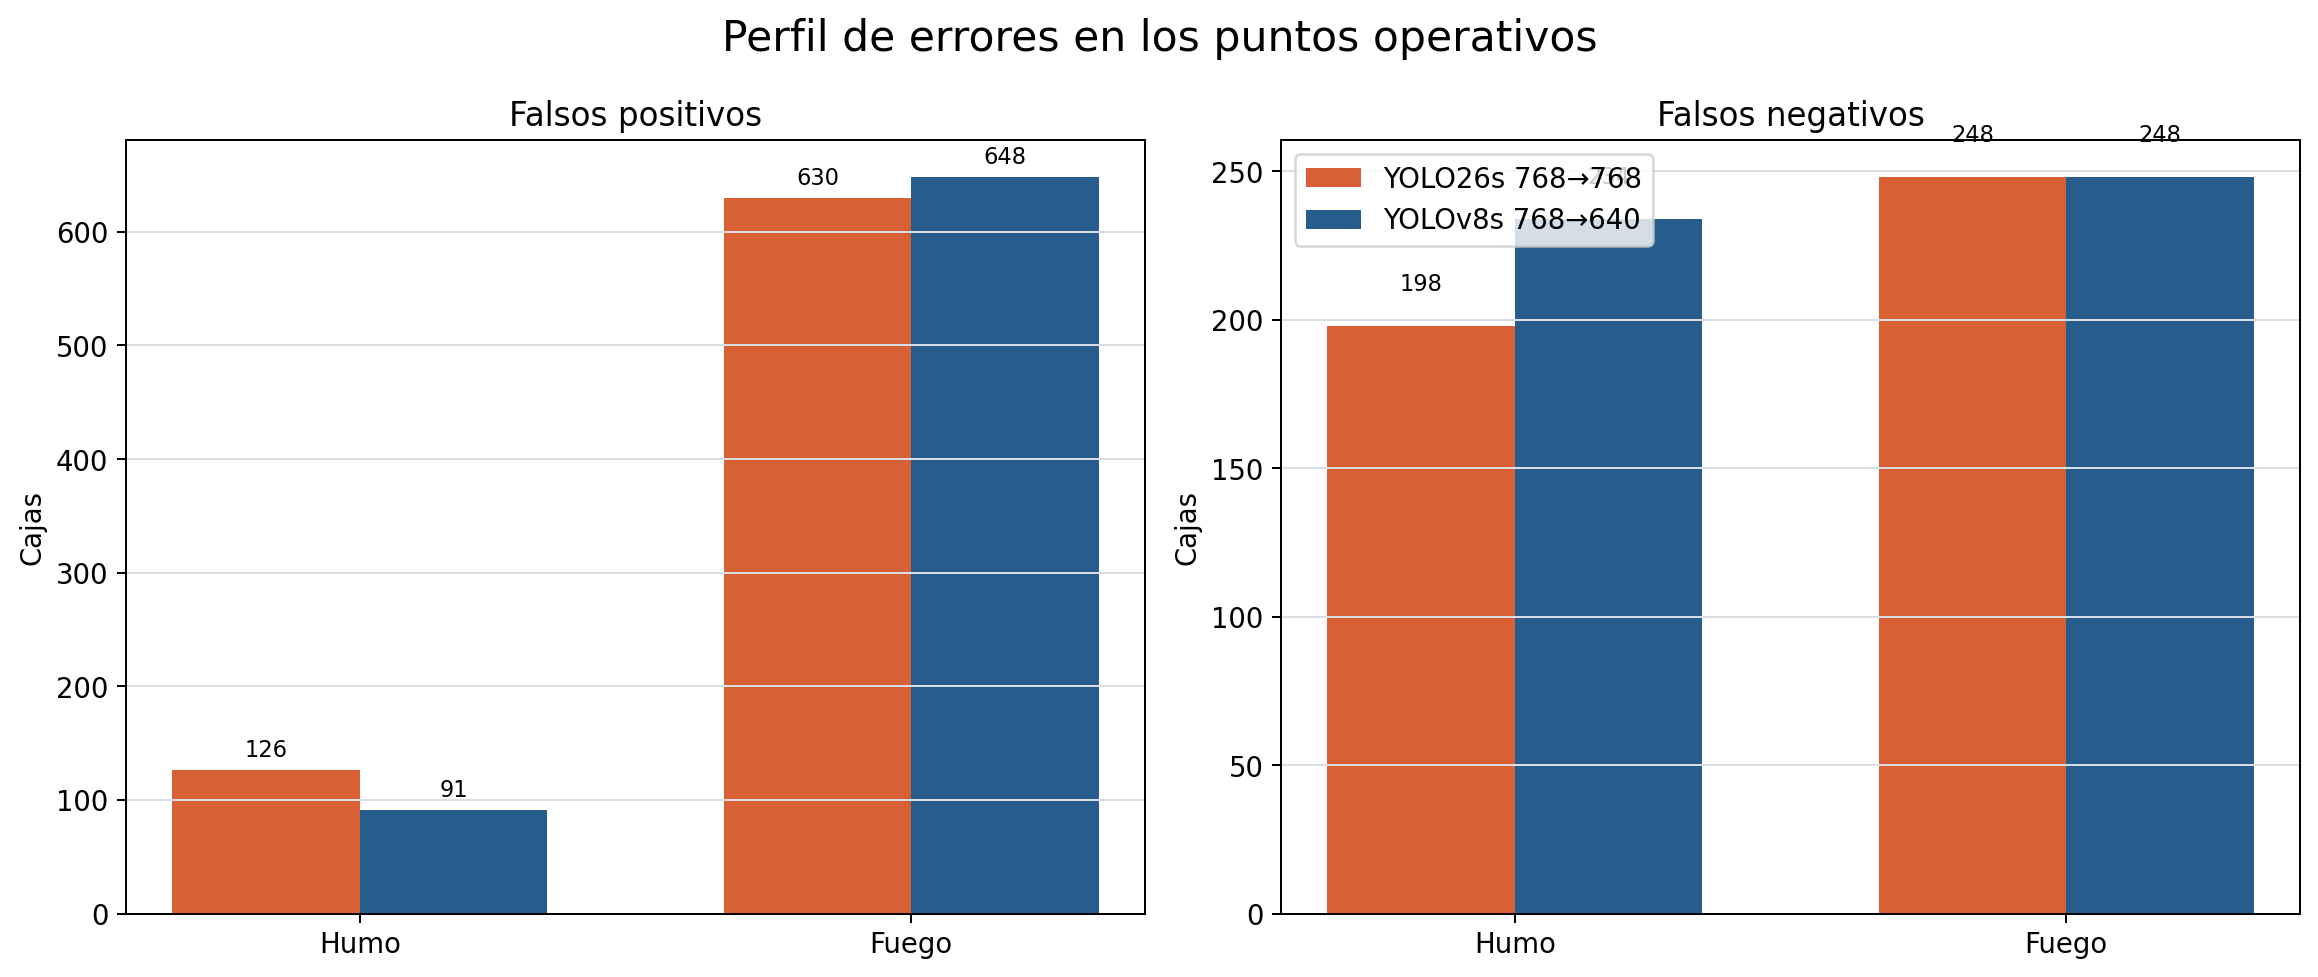

Categoría manual,Imágenes
localization_extent,10
duplicate,4
possible_unannotated_fire,4
artificial_light,3
class_ambiguity,3
red_object_or_reflection,2
haze_or_possible_smoke,1


In [8]:
display(errors.rename(columns={
    "label": "Modelo", "smoke_fp": "FP humo", "smoke_fn": "FN humo",
    "fire_fp": "FP fuego", "fire_fn": "FN fuego",
    "positive_image_fp_boxes": "FP en positivas", "negative_image_fp_boxes": "FP en negativas",
    "negative_images_with_alarm": "Negativas con alarma",
}).drop(columns=["candidate"]).style.hide(axis="index"))
display(Image(filename=str(RUN_DIR / "figures" / "03_fp_fn_comparison.png"), width=1050))

manual_review = pd.read_csv(RUN_DIR / "manual_fp_review_summary.csv")
display(manual_review[["manual_category", "images"]].rename(
    columns={"manual_category": "Categoría manual", "images": "Imágenes"}
).style.hide(axis="index"))


La mayoría de las cajas falsas aparecen en imágenes que sí tienen un incendio.
Una revisión manual de los errores de YOLO26s encontró sobre todo: cajas de
distinto tamaño que la real, cajas duplicadas, anotaciones posiblemente
incompletas, confusión entre humo y fuego, luces artificiales y objetos rojos.
Esa revisión se hizo con un umbral común de 0,16, no con el punto final
0,36/0,16.

### 7. Comparación imagen a imagen

In [9]:
paired_table = paired[["class_name", "unit", "n", "baseline_rate", "candidate_rate", "gains", "losses", "p_value"]].copy()
paired_table["class_name"] = paired_table.class_name.map({"smoke": "Humo", "fire": "Fuego"})
paired_table["unit"] = paired_table.unit.map({"positive_image": "Imagen positiva", "box": "Caja"})
paired_table = paired_table.rename(columns={"class_name": "Clase", "unit": "Unidad", "baseline_rate": "YOLOv8s",
    "candidate_rate": "YOLO26s", "gains": "Ganancias", "losses": "Pérdidas", "p_value": "p exacta"})
display(paired_table.style.format({"YOLOv8s": "{:.2%}", "YOLO26s": "{:.2%}",
                                   "p exacta": "{:.3g}"}).hide(axis="index"))


Clase,Unidad,n,YOLOv8s,YOLO26s,Ganancias,Pérdidas,p exacta
Humo,Imagen positiva,844,87.68%,91.00%,45,17,0.000497
Humo,Caja,960,82.19%,85.42%,56,25,0.000752
Fuego,Imagen positiva,470,91.70%,93.83%,15,5,0.0414
Fuego,Caja,1155,72.12%,78.53%,116,42,3.29e-09


Comparación adicional, de un análisis anterior con ambos modelos evaluados a
768 px y el límite del 2 %: YOLO26s detectó más casos en las cuatro
comparaciones. Tres de las cuatro diferencias siguen siendo significativas tras
la corrección de Bonferroni, pero este test no se usó como criterio de
selección.

## Conclusiones

In [10]:
display(Markdown(
    f"1. **Candidato congelado:** `{summary['selected_experiment_id']}`.  \n"
    f"2. **Configuración:** 768 px, humo `{summary['selected_smoke_threshold']:.2f}`, "
    f"fuego `{summary['selected_fire_threshold']:.2f}`.  \n"
    "3. **Criterio satisfecho:** 7/783 negativas con alarma (0,894 %).  \n"
    "4. **Siguiente paso:** ejecutar esta configuración una sola vez sobre test, "
    "sin reajustar pesos, resolución ni umbrales."
))


1. **Candidato congelado:** `yolo26s_dfire_seed42_20260912T165304Z`.  
2. **Configuración:** 768 px, humo `0.36`, fuego `0.16`.  
3. **Criterio satisfecho:** 7/783 negativas con alarma (0,894 %).  
4. **Siguiente paso:** ejecutar esta configuración una sola vez sobre test, sin reajustar pesos, resolución ni umbrales.